## **Importing Libraries**

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## **No. of Columns and Rows in train and test dataset**

In [61]:
df_train.shape,df_test.shape

((550068, 12), (233599, 11))

In [62]:
df_train.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [63]:
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


## **Missing value Imputation**

In [64]:
df_train.isnull().mean()*100

User_ID                        0.000000
Product_ID                     0.000000
Gender                         0.000000
Age                            0.000000
Occupation                     0.000000
City_Category                  0.000000
Stay_In_Current_City_Years     0.000000
Marital_Status                 0.000000
Product_Category_1             0.000000
Product_Category_2            31.566643
Product_Category_3            69.672659
Purchase                       0.000000
dtype: float64

In [65]:
df_test.isnull().mean()*100

User_ID                        0.000000
Product_ID                     0.000000
Gender                         0.000000
Age                            0.000000
Occupation                     0.000000
City_Category                  0.000000
Stay_In_Current_City_Years     0.000000
Marital_Status                 0.000000
Product_Category_1             0.000000
Product_Category_2            30.969311
Product_Category_3            69.590195
dtype: float64

In [66]:
df_train['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [67]:
df_test['Product_Category_2'].unique()

array([11.,  5., 14.,  9.,  3.,  4., 13.,  2., nan,  8., 15., 17., 12.,
       16.,  6., 10., 18.,  7.])

In [68]:
df_train['Product_Category_2'].mode()[0]

8.0

In [69]:
df_test['Product_Category_2'].mode()[0]

8.0

In [70]:
df_train['Product_Category_3'].mode()[0]

16.0

In [71]:
df_test['Product_Category_3'].mode()[0]

16.0

In [72]:
df_train['Product_Category_2']=df_train['Product_Category_2'].fillna(df_train['Product_Category_2'].mode()[0])
df_train.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2                 0
Product_Category_3            383247
Purchase                           0
dtype: int64

In [73]:
df_train['Product_Category_3']=df_train['Product_Category_3'].fillna(df_train['Product_Category_3'].mode()[0])
df_train.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [74]:
df_test['Product_Category_2']=df_test['Product_Category_2'].fillna(df_test['Product_Category_2'].mode()[0])
df_test.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2                 0
Product_Category_3            162562
dtype: int64

In [75]:
df_test['Product_Category_3']=df_test['Product_Category_3'].fillna(df_test['Product_Category_3'].mode()[0])
df_test.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
dtype: int64

In [76]:
if 'User_ID' in df_train.columns:
    df_train = df_train.drop(['User_ID', 'Product_Category_3'], axis=1)
if 'User_ID' in df_test.columns:
    df_test = df_test.drop(['User_ID', 'Product_Category_3'], axis=1)

## **Feature Engineering**

In [77]:
## Splitting Train and Test data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df_train,df_train['Purchase'],test_size=0.25,random_state=0)

In [78]:
x_train.shape,y_train.shape

((412551, 10), (412551,))

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [80]:
transformer=ColumnTransformer(transformers=[
    ("tnf1",OneHotEncoder(sparse=False,drop="first"),["Age","Gender","City_Category","Product_Category_1","Product_Category_2"])

],remainder="passthrough")

In [81]:
transformer.fit_transform(x_train)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


array([[0.0, 0.0, 1.0, ..., '1', 0, 12119],
       [0.0, 1.0, 0.0, ..., '1', 0, 15764],
       [0.0, 0.0, 0.0, ..., '4+', 1, 8899],
       ...,
       [0.0, 0.0, 0.0, ..., '1', 1, 6991],
       [1.0, 0.0, 0.0, ..., '0', 1, 13251],
       [0.0, 0.0, 0.0, ..., '0', 0, 9905]], dtype=object)

In [82]:
transformer.transform(x_test)

array([[1.0, 0.0, 0.0, ..., '3', 0, 15228],
       [0.0, 0.0, 0.0, ..., '0', 0, 1088],
       [0.0, 1.0, 0.0, ..., '2', 0, 16426],
       ...,
       [0.0, 1.0, 0.0, ..., '1', 1, 15817],
       [1.0, 0.0, 0.0, ..., '3', 1, 6191],
       [0.0, 1.0, 0.0, ..., '0', 1, 2854]], dtype=object)

In [83]:
import numpy as np
features=['Age','Gender','City_Category','Product_Category_1','Product_Category_2']

for feature in features:
    labels_ordered=df_train.groupby([feature])['Purchase'].mean().sort_values().index
    labels_ordered={k:i for i,k in enumerate(labels_ordered,0)}
    df_train[feature]=df_train[feature].map(labels_ordered)


In [84]:
df_train=df_train[df_train.Product_Category_1 > 2.5]
df_train.reset_index(drop=True,inplace=True)

## **Feature Scaling**

In [85]:
feature_scale=[feature for feature in df_train.columns if feature not in ["Product_ID","Purchase","Stay_In_Current_City_Years","Age"]]

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(df_train[feature_scale])

MinMaxScaler()

## **Feature Selection**

In [86]:
##for feature selection
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

In [87]:
## Splitting Train and Test data
x_train=df_train.drop(['Product_ID','Purchase','Stay_In_Current_City_Years'],axis=1)
y_train=df_train['Purchase']

In [88]:
feature_sel_model = SelectFromModel(Lasso(alpha=0.1, random_state=0)) # remember to set the seed, the random state in this function
feature_sel_model.fit(x_train, y_train)


SelectFromModel(estimator=Lasso(alpha=0.1, random_state=0))

In [89]:
selected_feat = x_train.columns[(feature_sel_model.get_support())]

# let's print some stats
print('total features: {}'.format((x_train.shape[1])))
print('selected features: {}'.format(len(selected_feat)))
print('features with coefficients shrank to zero: {}'.format(
    np.sum(feature_sel_model.estimator_.coef_ == 0)))

total features: 7
selected features: 7
features with coefficients shrank to zero: 0


In [90]:
x_train=x_train[selected_feat]

## **Observation**

In [91]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory
import matplotlib.gridspec as gridspec
from datetime import datetime
from scipy.stats import skew  # for some statistics
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from mlxtend.regressor import StackingCVRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import scipy.stats as stats
import sklearn.linear_model as linear_model
import matplotlib.style as style
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import missingno as msno


<ipython-input-92-88cc59a251a9>:21: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[:,feature], norm_hist=True, ax = ax1)


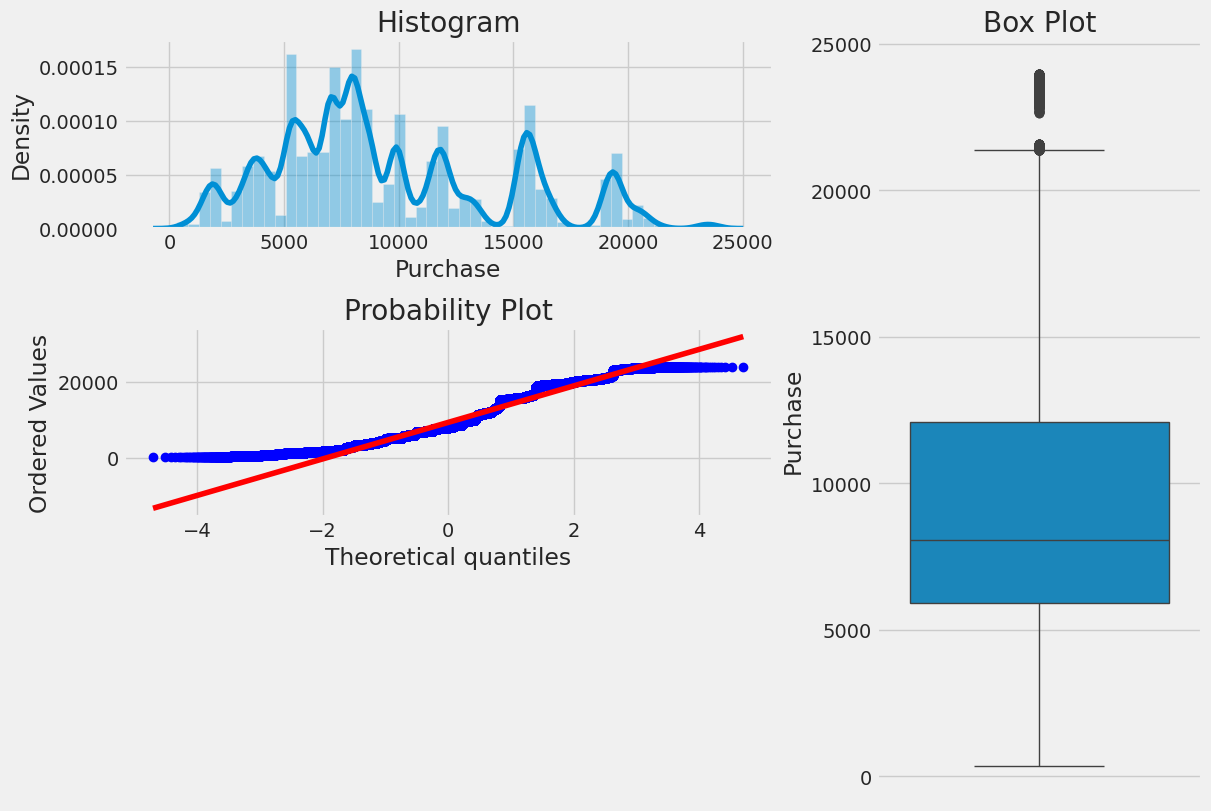

In [92]:
def plotting_3_chart(df, feature):
    ## Importing seaborn, matplotlab and scipy modules.
    import seaborn as sns
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from scipy import stats
    import matplotlib.style as style
    style.use('fivethirtyeight')

    ## Creating a customized chart. and giving in figsize and everything.
    fig = plt.figure(constrained_layout=True, figsize=(12,8))
    ## creating a grid of 3 cols and 3 rows.
    grid = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
    #gs = fig3.add_gridspec(3, 3)

    ## Customizing the histogram grid.
    ax1 = fig.add_subplot(grid[0, :2])
    ## Set the title.
    ax1.set_title('Histogram')
    ## plot the histogram.
    sns.distplot(df.loc[:,feature], norm_hist=True, ax = ax1)

    # customizing the QQ_plot.
    ax2 = fig.add_subplot(grid[1, :2])
    ## Set the title.
    ax2.set_title('QQ_plot')
    ## Plotting the QQ_Plot.
    stats.probplot(df.loc[:,feature], plot = ax2)

    ## Customizing the Box Plot.
    ax3 = fig.add_subplot(grid[:, 2])
    ## Set title.
    ax3.set_title('Box Plot')
    ## Plotting the box plot.
    sns.boxplot(df.loc[:,feature], orient='v', ax = ax3 );

plotting_3_chart(df_train, 'Purchase')

In [93]:
df_train["Purchase"].skew()

0.6521510615863566

In [94]:
df_train["Purchase"].kurt()

-0.3439310670410465

In [95]:
(df_train.corr()**2)["Purchase"].sort_values(ascending=False)[1:]

<ipython-input-95-2738c14515f4>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  (df_train.corr()**2)["Purchase"].sort_values(ascending=False)[1:]


Product_Category_1    6.008448e-01
Product_Category_2    1.296969e-01
City_Category         4.798063e-03
Gender                3.694642e-03
Age                   5.570585e-04
Occupation            4.891357e-04
Marital_Status        2.080387e-07
Name: Purchase, dtype: float64

<ipython-input-96-4114d7ba0e14>:8: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  mask = np.zeros_like(df_train.corr())
<ipython-input-96-4114d7ba0e14>:12: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_train.corr(),


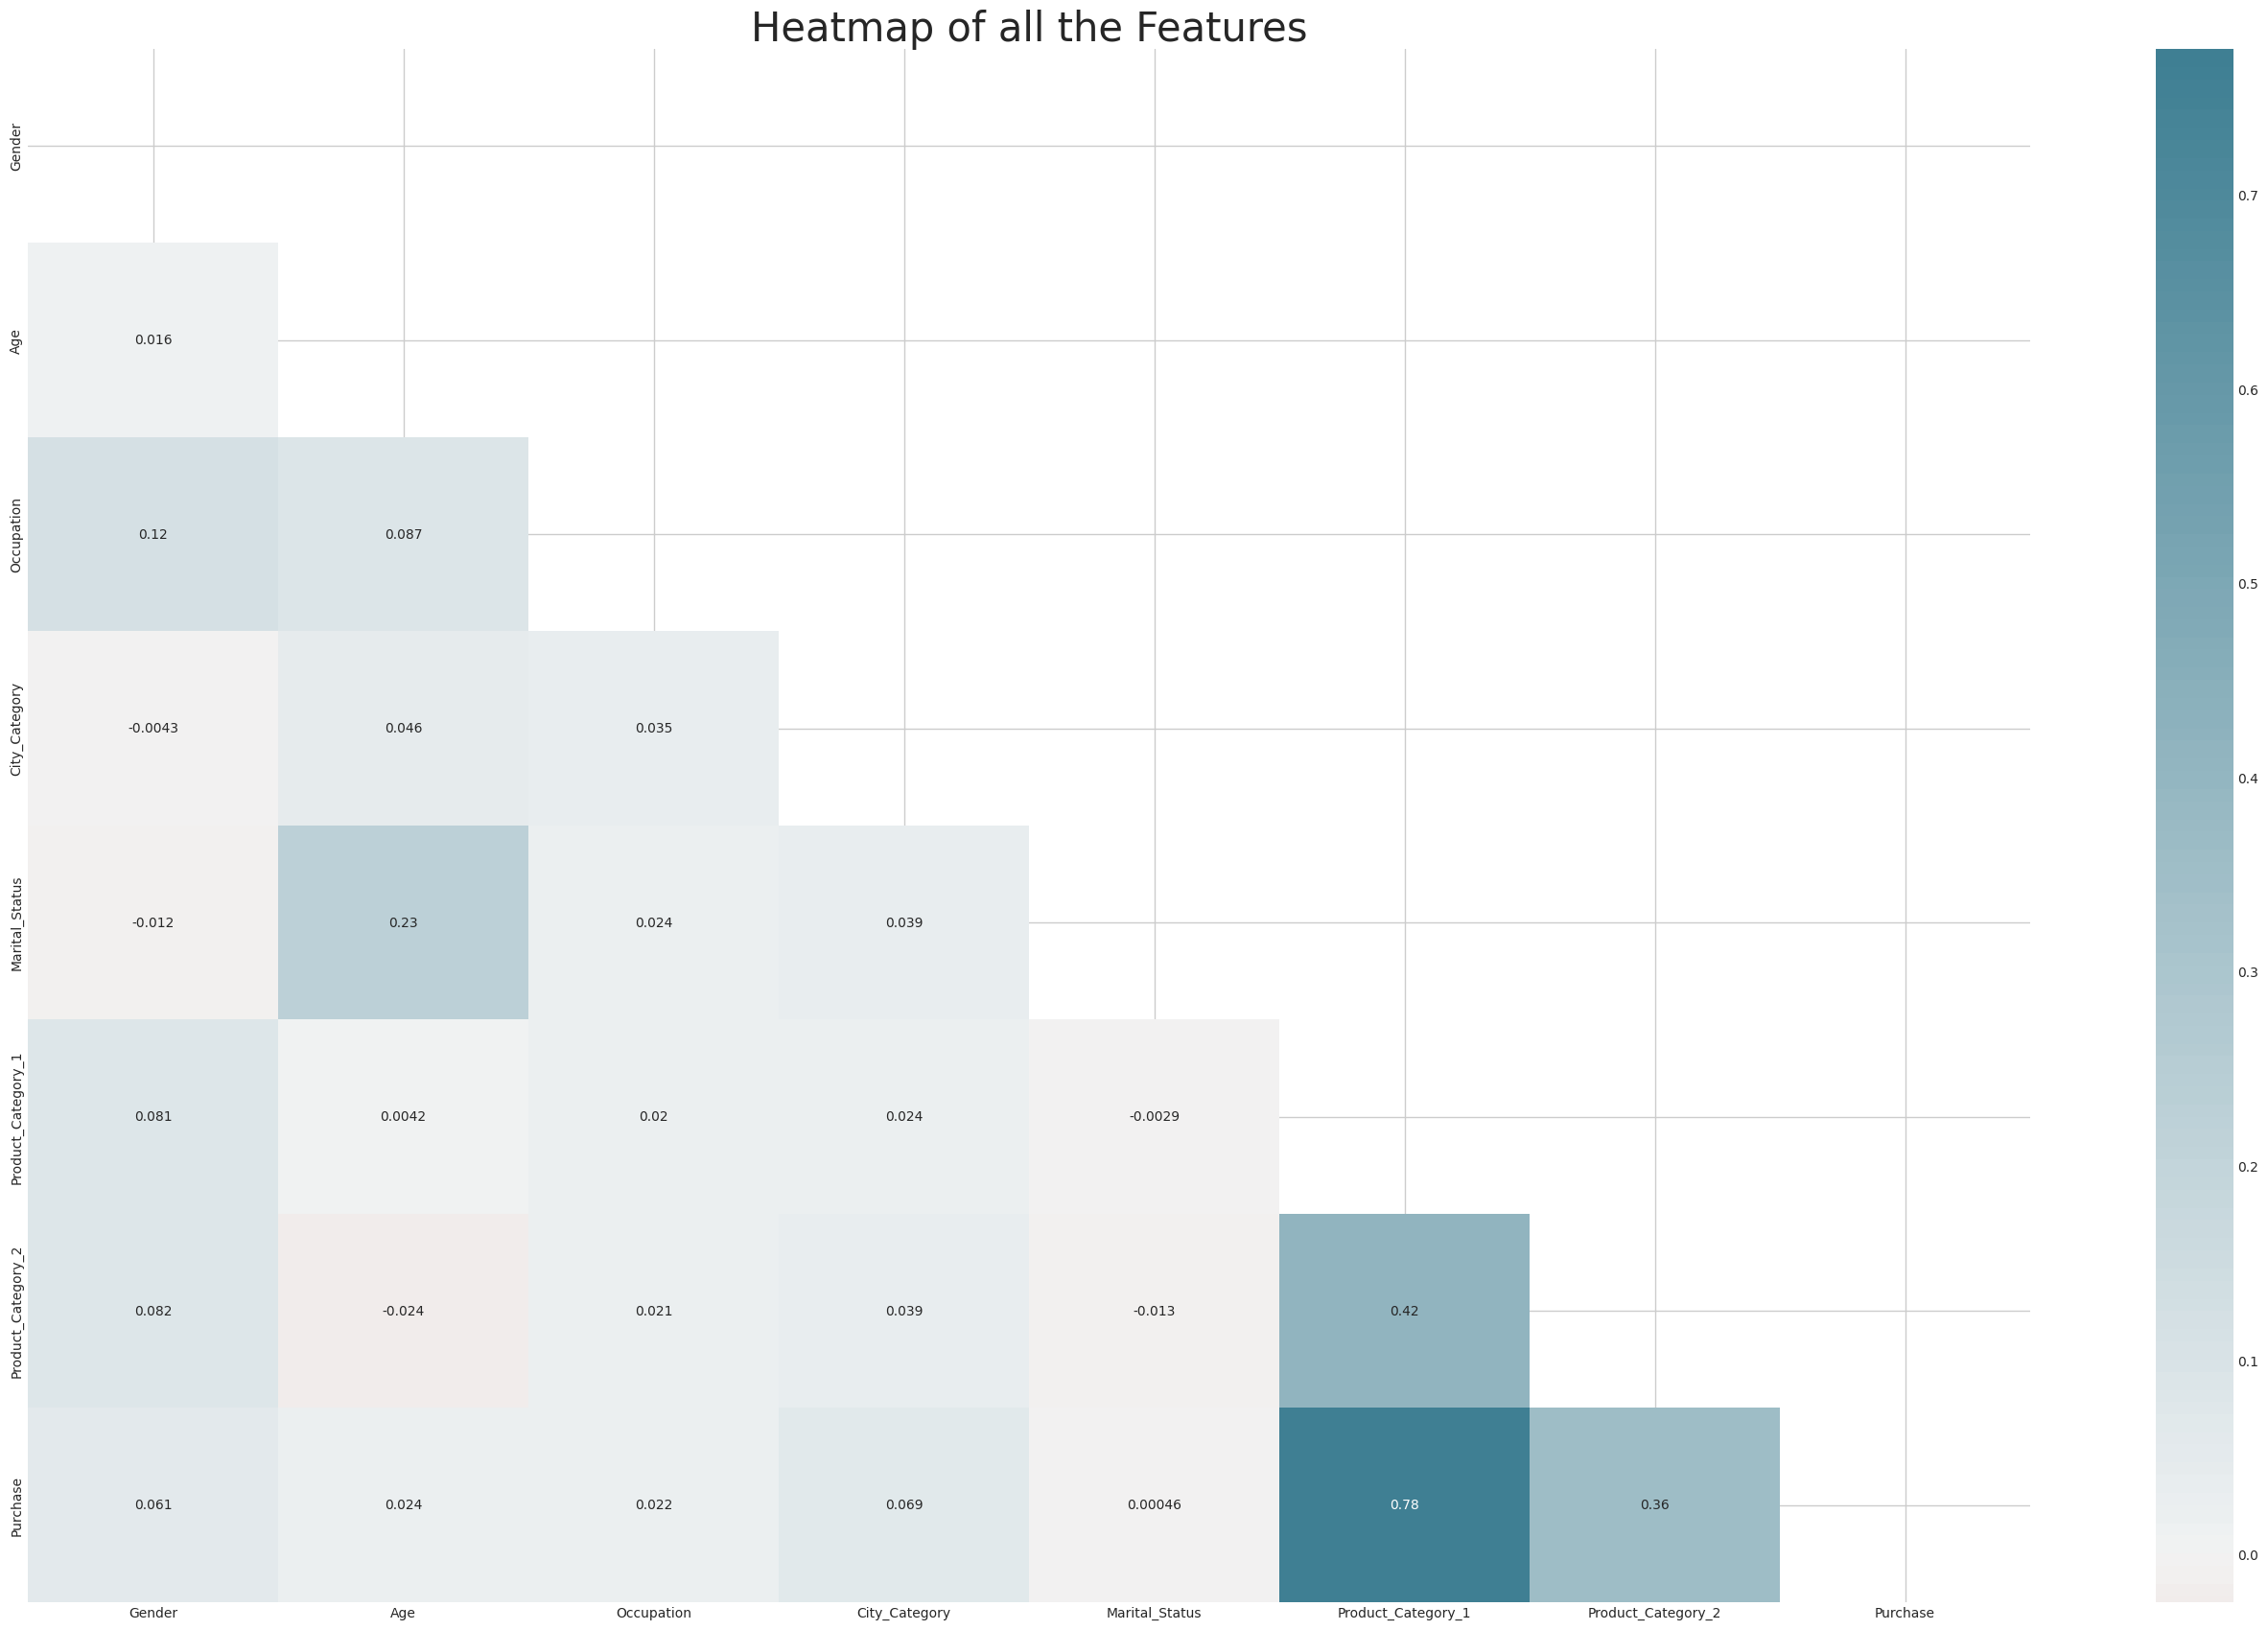

In [96]:
## Plot fig sizing.
style.use('ggplot')
sns.set_style('whitegrid')
plt.subplots(figsize = (30,20))
## Plotting heatmap.

# Generate a mask for the upper triangle (taken from seaborn example gallery)
mask = np.zeros_like(df_train.corr())
mask[np.triu_indices_from(mask)] = True


sns.heatmap(df_train.corr(),
            cmap=sns.diverging_palette(20, 220, n=200),
            mask = mask,
            annot=True,
            center = 0,
           );
## Give title.
plt.title("Heatmap of all the Features", fontsize = 30);

In [97]:
def customized_scatterplot(y, x):
        ## Sizing the plot.
    style.use('fivethirtyeight')
    plt.subplots(figsize = (12,8))
    ## Plotting target variable with predictor variable(OverallQual)
    sns.scatterplot(y = y, x = x);

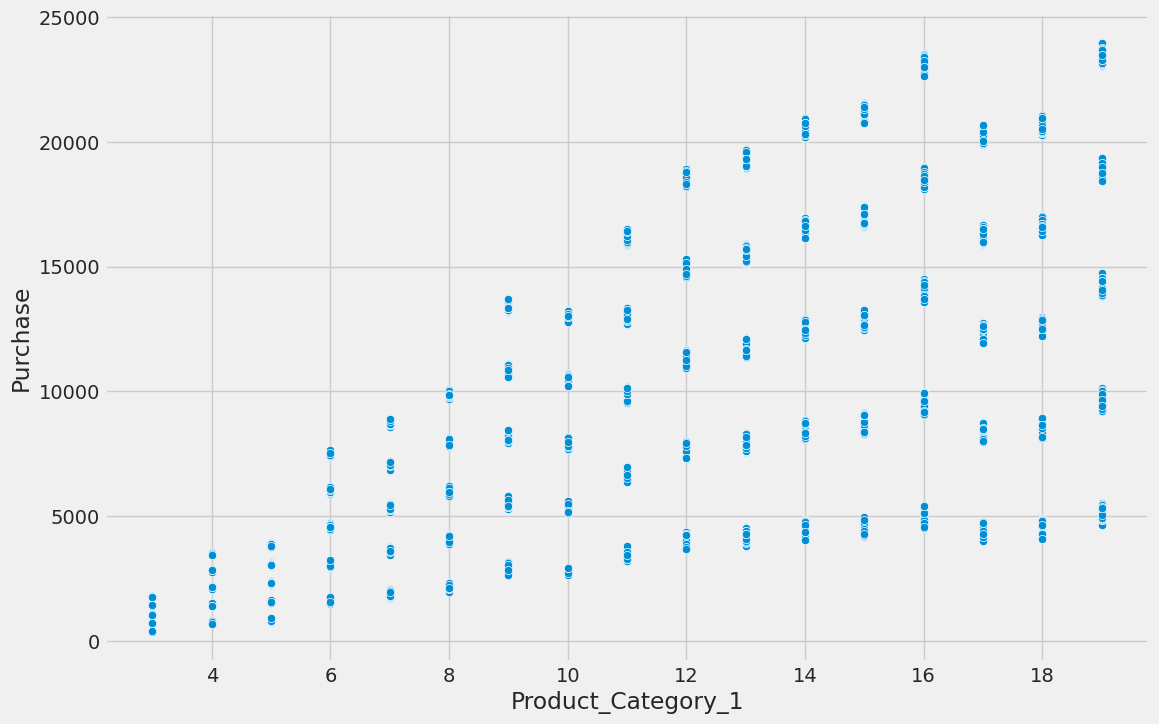

In [98]:
customized_scatterplot(df_train.Purchase,df_train.Product_Category_1)

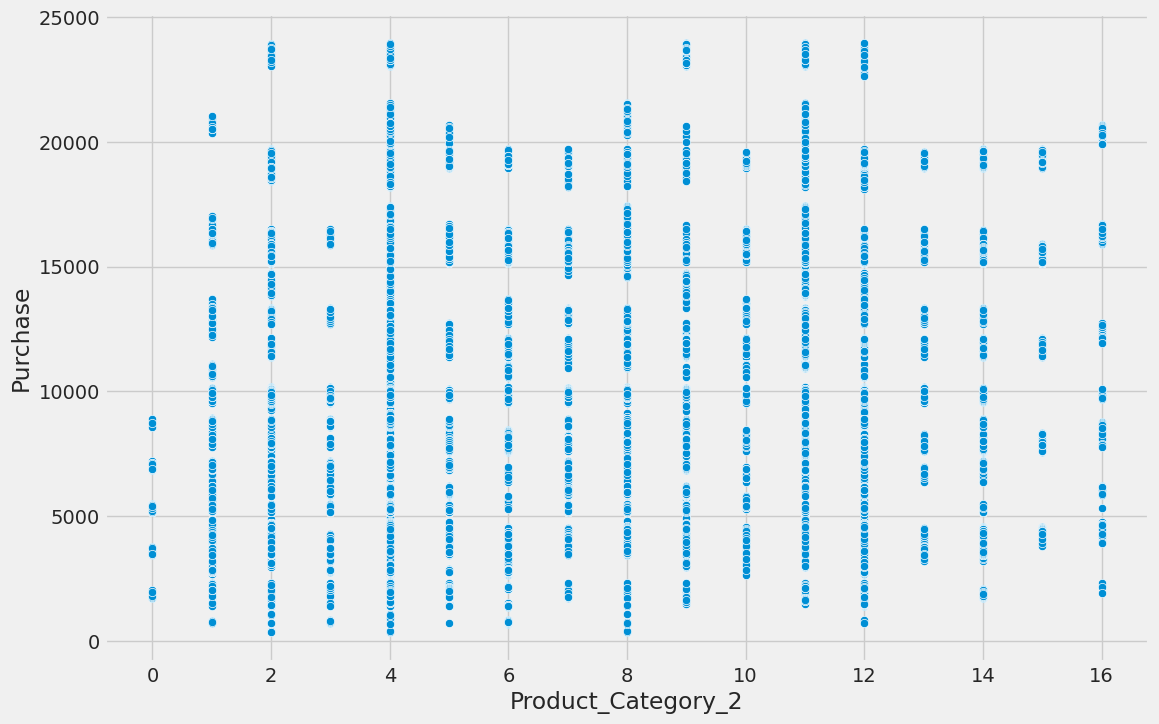

In [99]:
customized_scatterplot(df_train.Purchase,df_train.Product_Category_2)

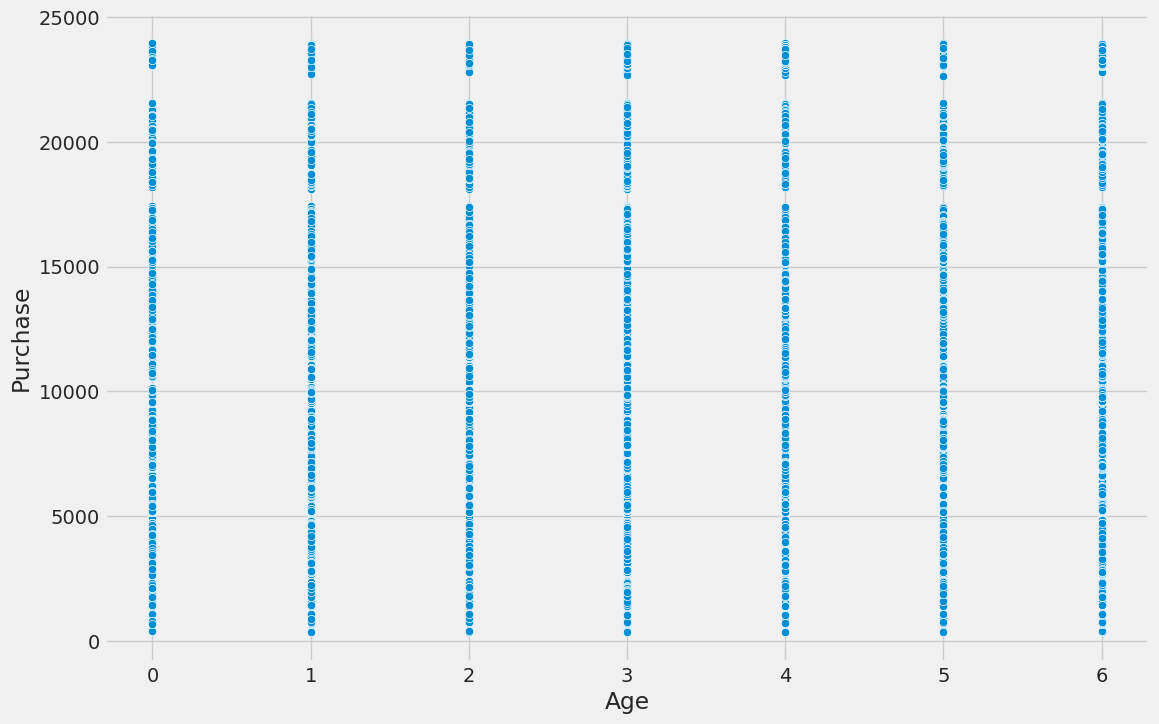

In [100]:
customized_scatterplot(df_train.Purchase,df_train.Age)

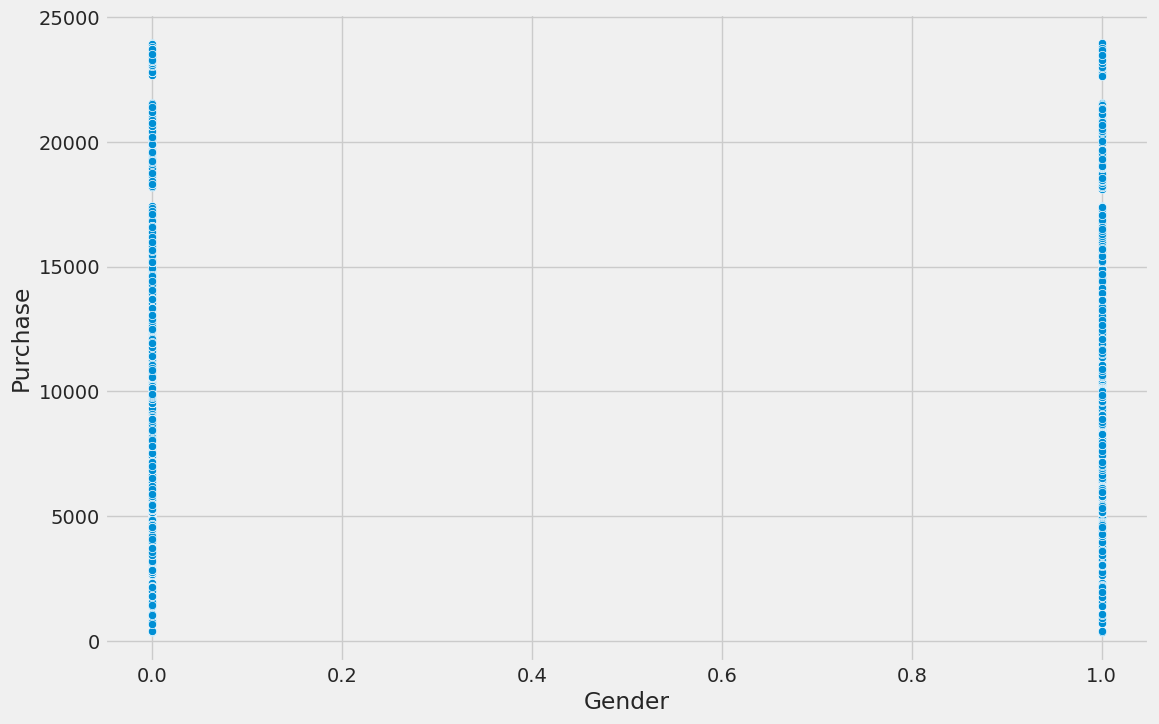

In [101]:
customized_scatterplot(df_train.Purchase,df_train.Gender)

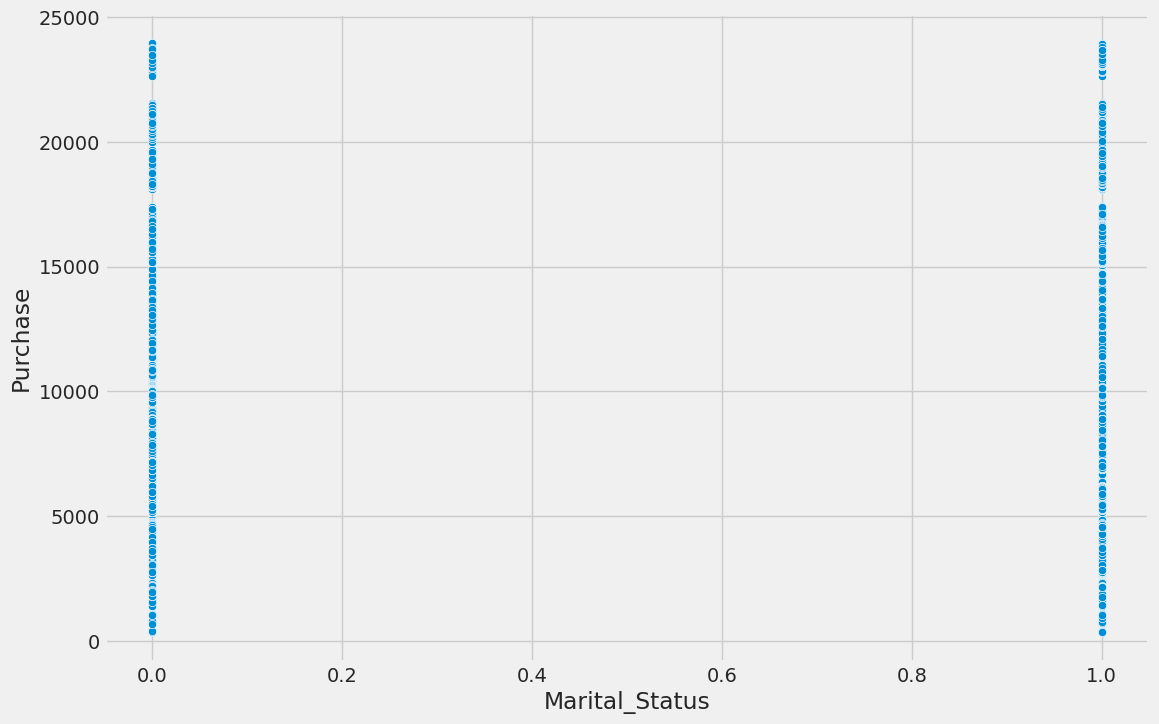

In [102]:
customized_scatterplot(df_train.Purchase,df_train.Marital_Status)

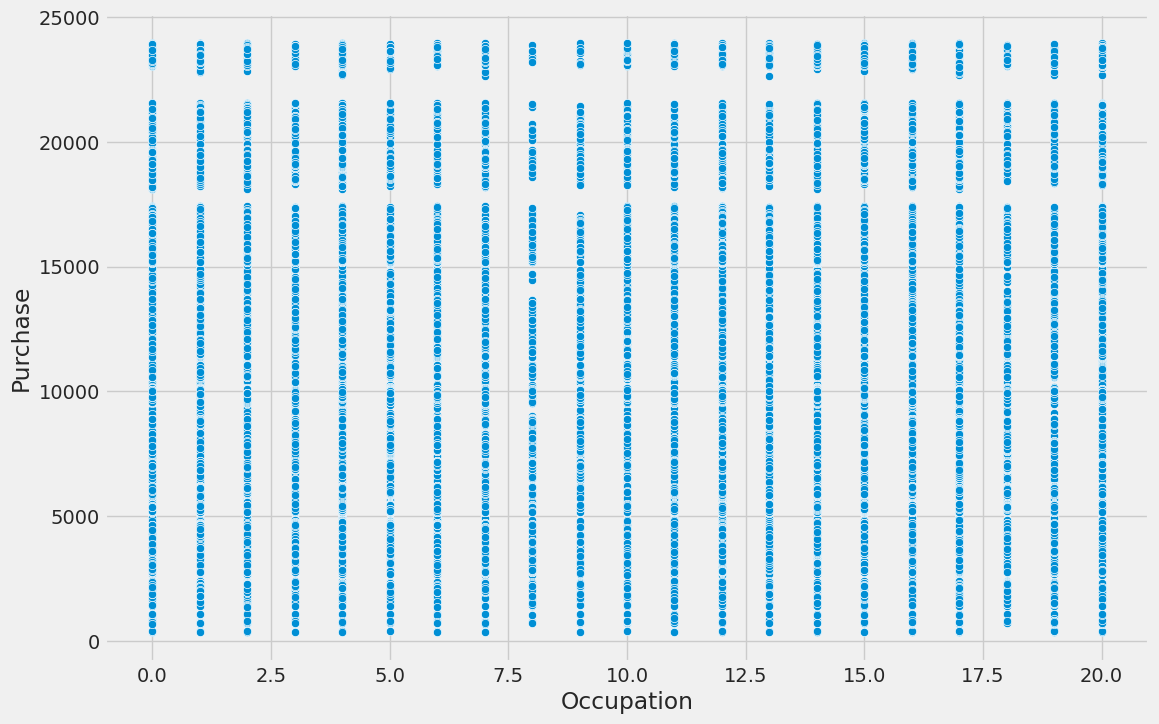

In [103]:
customized_scatterplot(df_train.Purchase,df_train.Occupation)

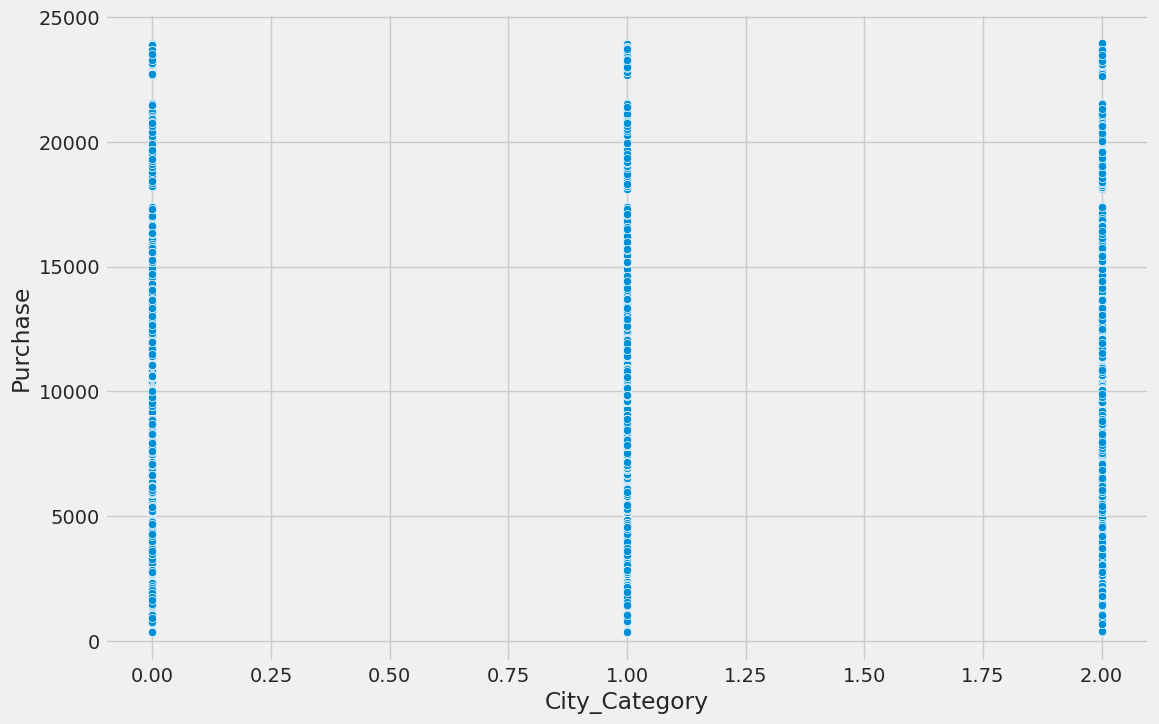

In [104]:
customized_scatterplot(df_train.Purchase,df_train.City_Category)

## **Assumption**

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

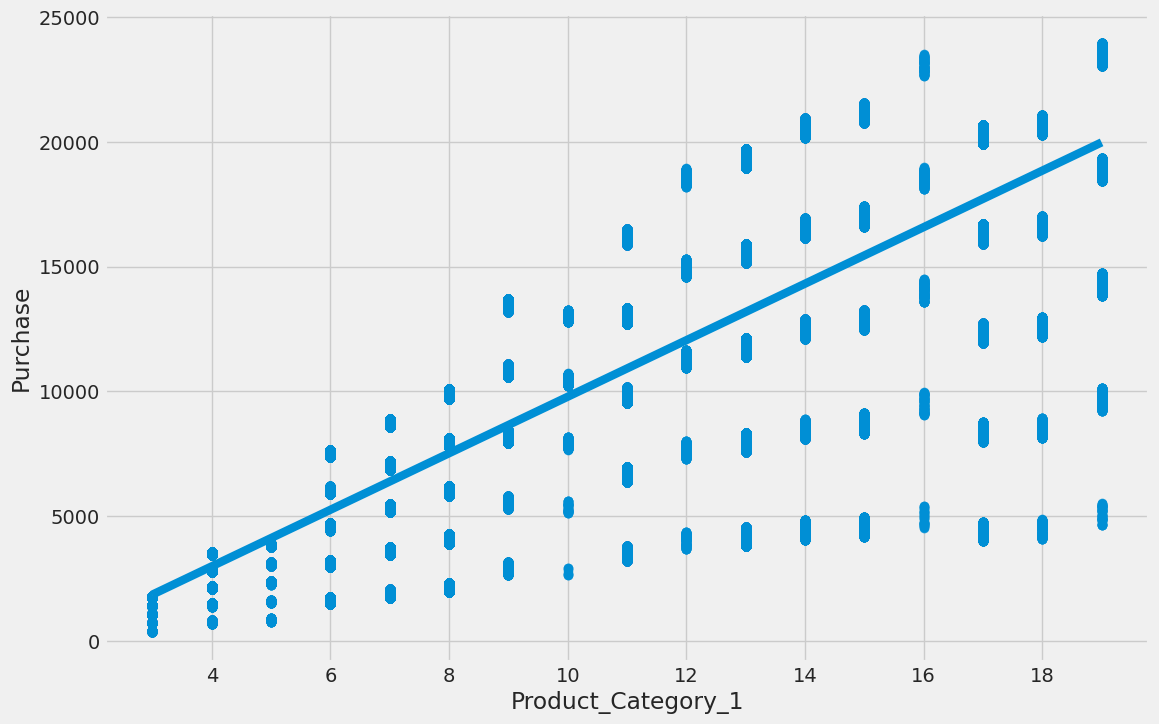

In [105]:
## Plot sizing.
fig, (ax1) = plt.subplots(figsize = (12,8), ncols=1,sharey=True)

sns.scatterplot(x=df_train.Product_Category_1, y = df_train.Purchase,  ax=ax1)
## Putting a regression line.
sns.regplot(x=df_train.Product_Category_1, y = df_train.Purchase, ax=ax1)

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

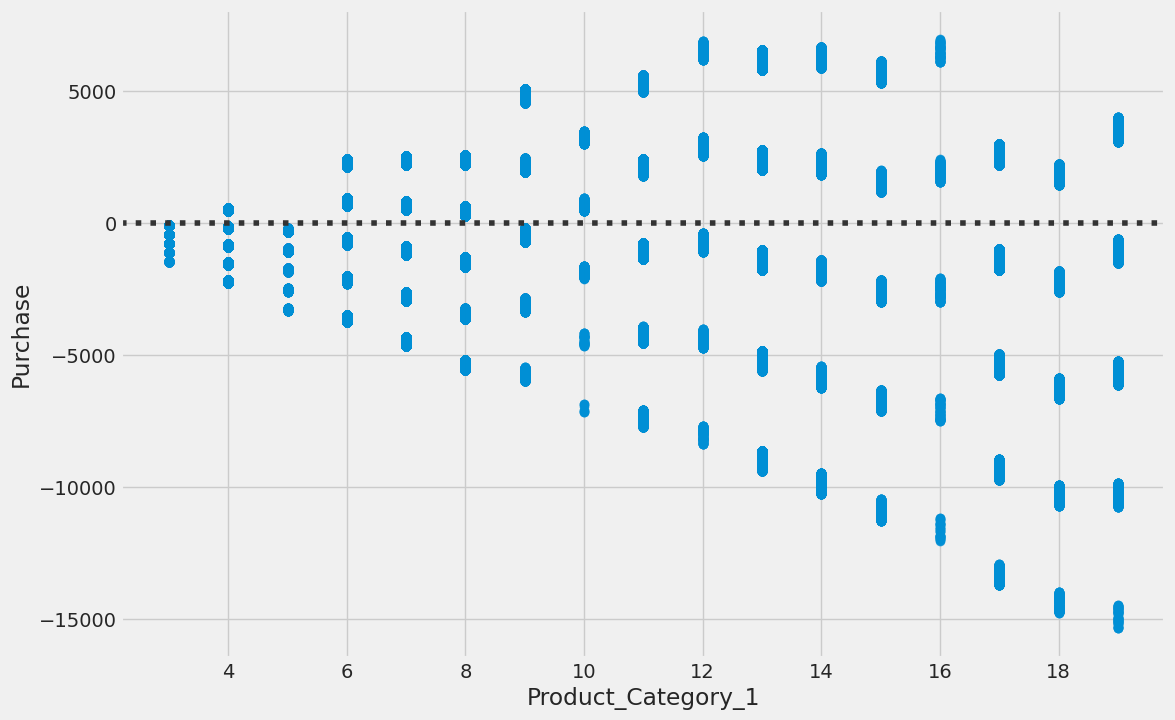

In [106]:
plt.subplots(figsize=(12,8))
sns.residplot(x=df_train.Product_Category_1,y=df_train.Purchase)

<ipython-input-92-88cc59a251a9>:21: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[:,feature], norm_hist=True, ax = ax1)


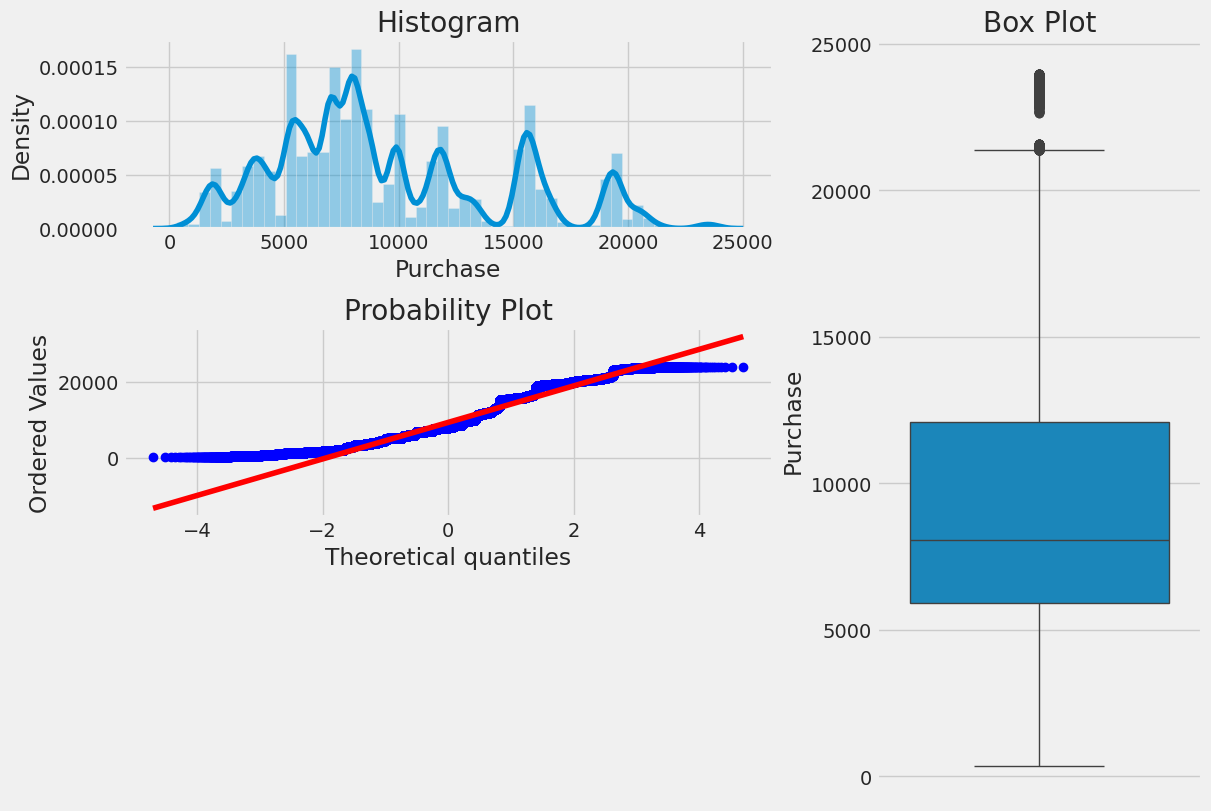

In [107]:
plotting_3_chart(df_train,"Purchase")

<ipython-input-92-88cc59a251a9>:21: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[:,feature], norm_hist=True, ax = ax1)


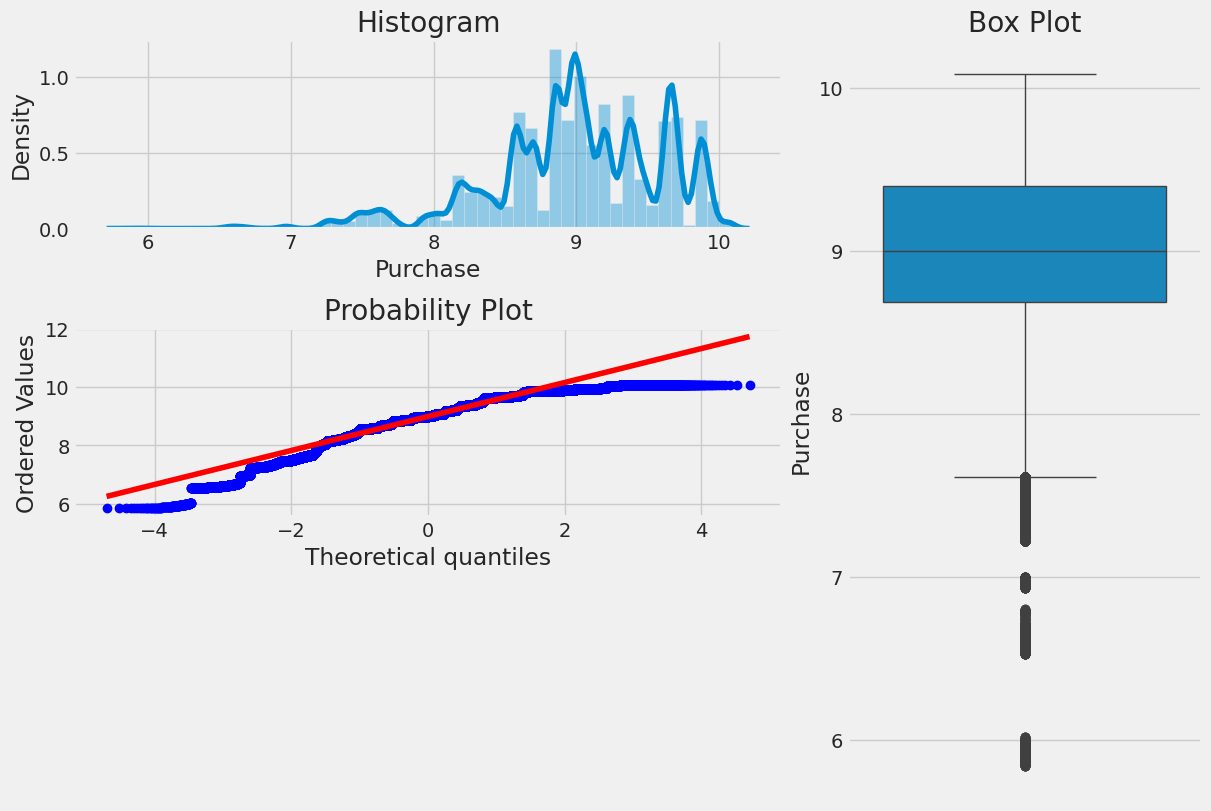

In [108]:
df_train["Purchase"]=np.log1p(df_train["Purchase"])
plotting_3_chart(df_train,"Purchase")

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

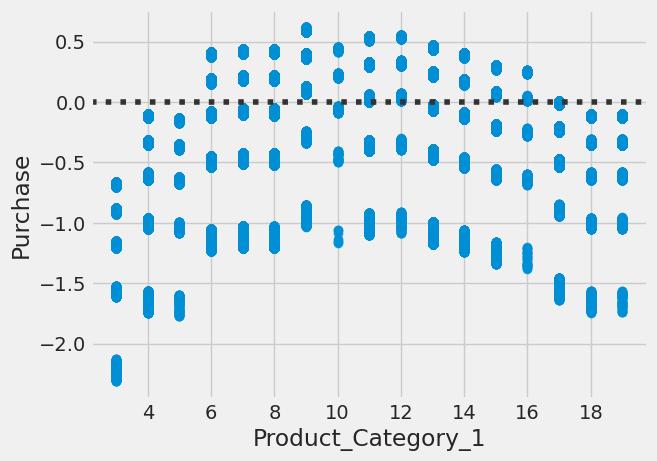

In [109]:
sns.residplot(x = df_train.Product_Category_1, y = df_train.Purchase)

In [110]:

## Deleting those two values with outliers.
train = df_train[df_train.Product_Category_1 < 4500]
train.reset_index(drop = True, inplace = True)

## save a copy of this dataset so that any changes later on can be compared side by side.
previous_train = train.copy()

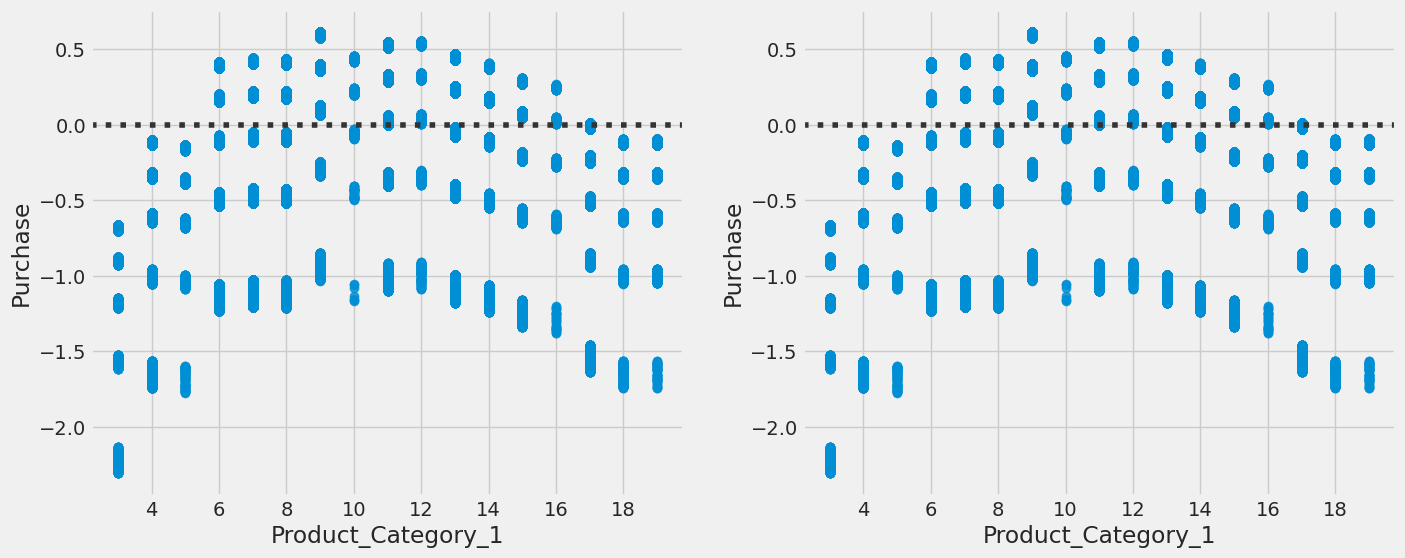

In [112]:
fig, (ax1, ax2) = plt.subplots(figsize = (15,6),
                               ncols=2,
                               sharey = False,
                               sharex=False
                              )
## doing the first scatter plot.
sns.residplot(x = previous_train.Product_Category_1, y = previous_train.Purchase, ax = ax1)
## doing the scatter plot for GrLivArea and SalePrice.
sns.residplot(x = df_train.Product_Category_1, y = df_train.Purchase, ax = ax2);

<ipython-input-113-4114d7ba0e14>:8: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  mask = np.zeros_like(df_train.corr())
<ipython-input-113-4114d7ba0e14>:12: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_train.corr(),


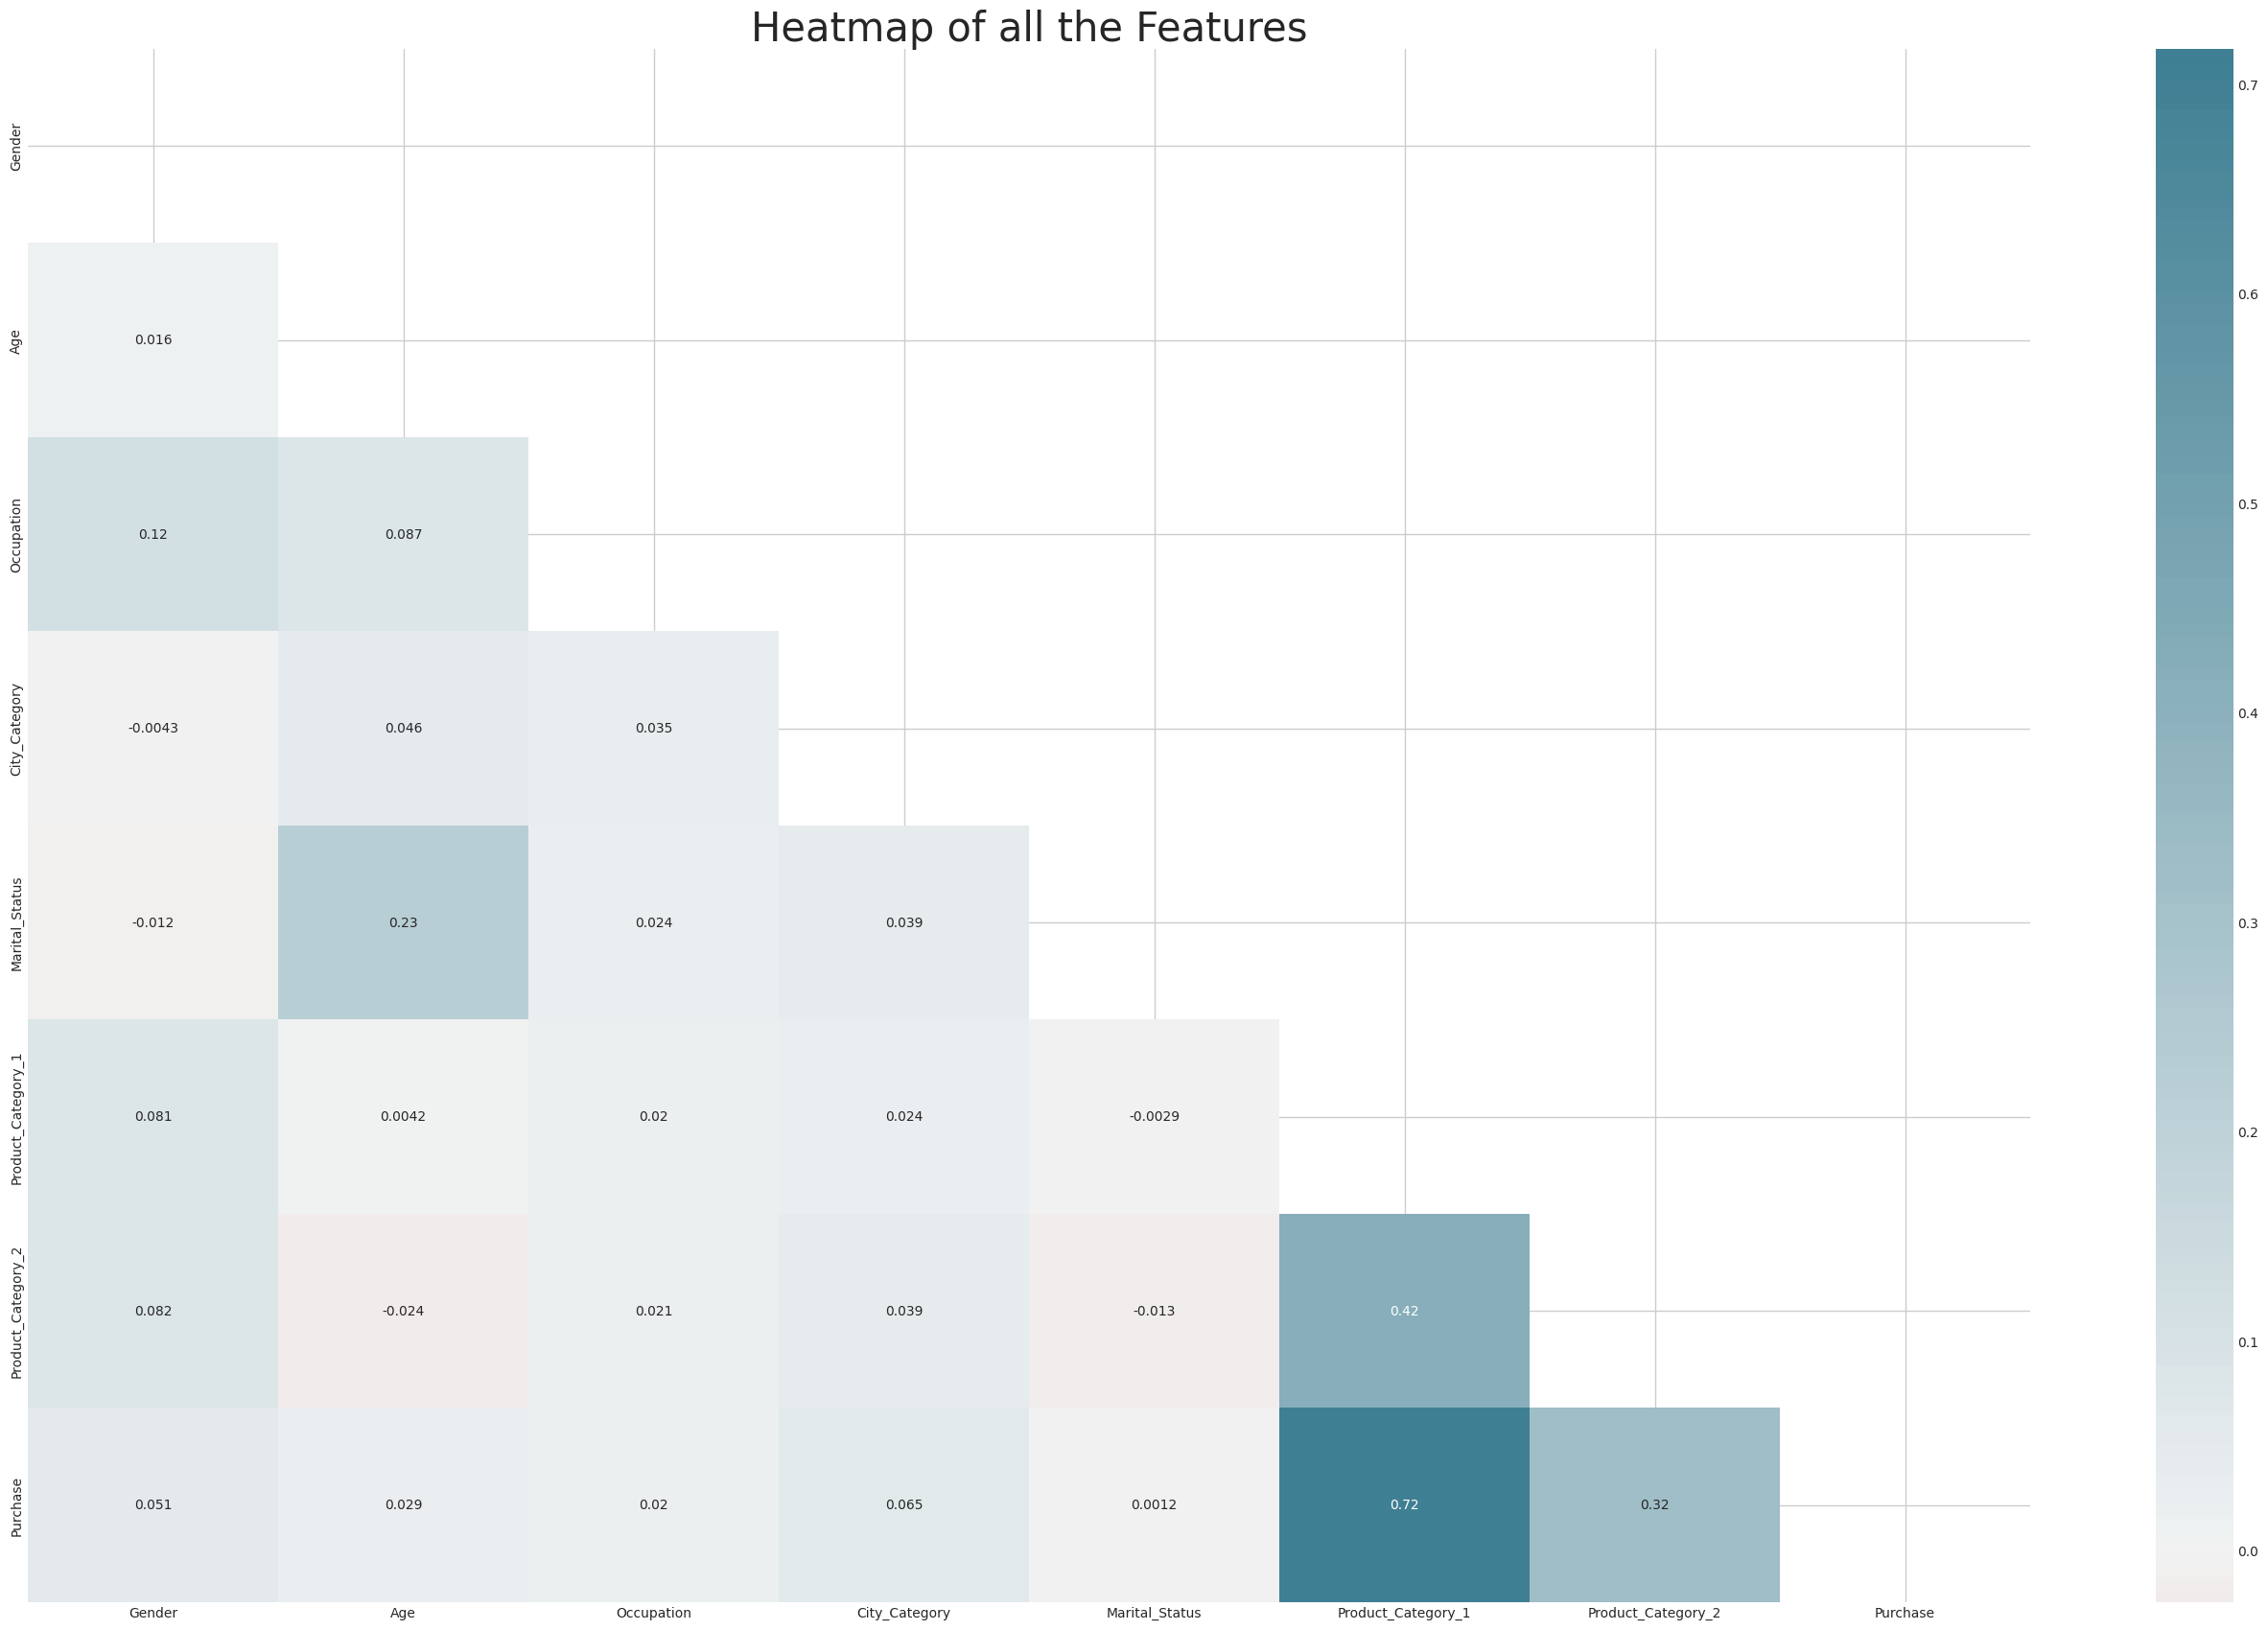

In [113]:
## Plot fig sizing.
style.use('ggplot')
sns.set_style('whitegrid')
plt.subplots(figsize = (30,20))
## Plotting heatmap.

# Generate a mask for the upper triangle (taken from seaborn example gallery)
mask = np.zeros_like(df_train.corr())
mask[np.triu_indices_from(mask)] = True


sns.heatmap(df_train.corr(),
            cmap=sns.diverging_palette(20, 220, n=200),
            mask = mask,
            annot=True,
            center = 0,
           );
## Give title.
plt.title("Heatmap of all the Features", fontsize = 30);

In [115]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df_train,df_train['Purchase'],test_size =0.25, random_state = 0)

In [116]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((405274, 10), (405274,), (135092, 10), (135092,))

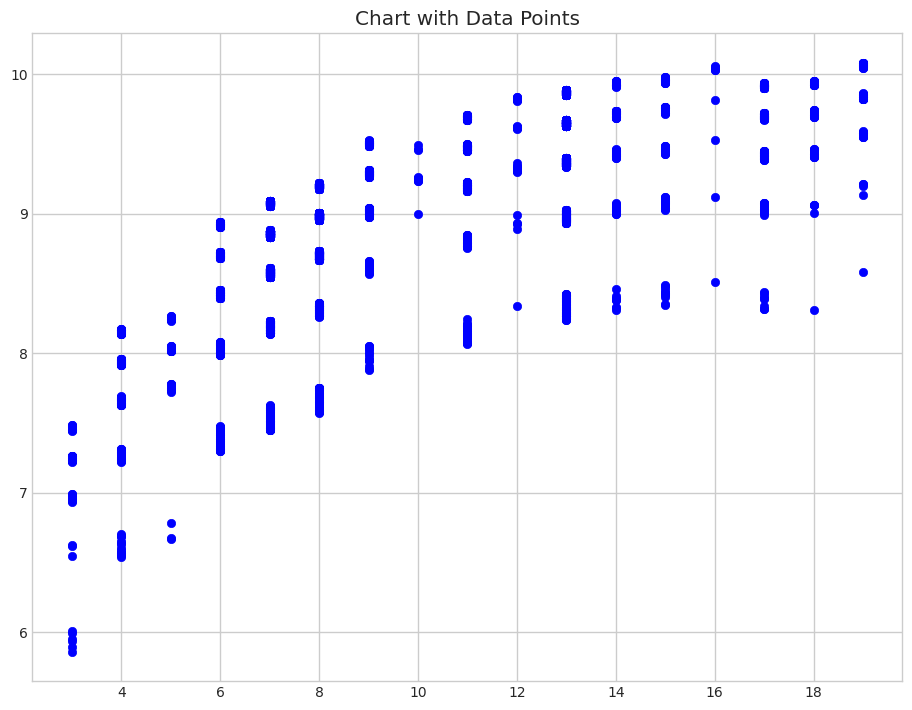

In [121]:
sample_train = df_train.sample(10000)
import seaborn as sns
plt.subplots(figsize = (10,8))
ax = plt.gca()
ax.scatter(sample_train.Product_Category_1.values, sample_train.Purchase.values, color ='b');
plt.title("Chart with Data Points");

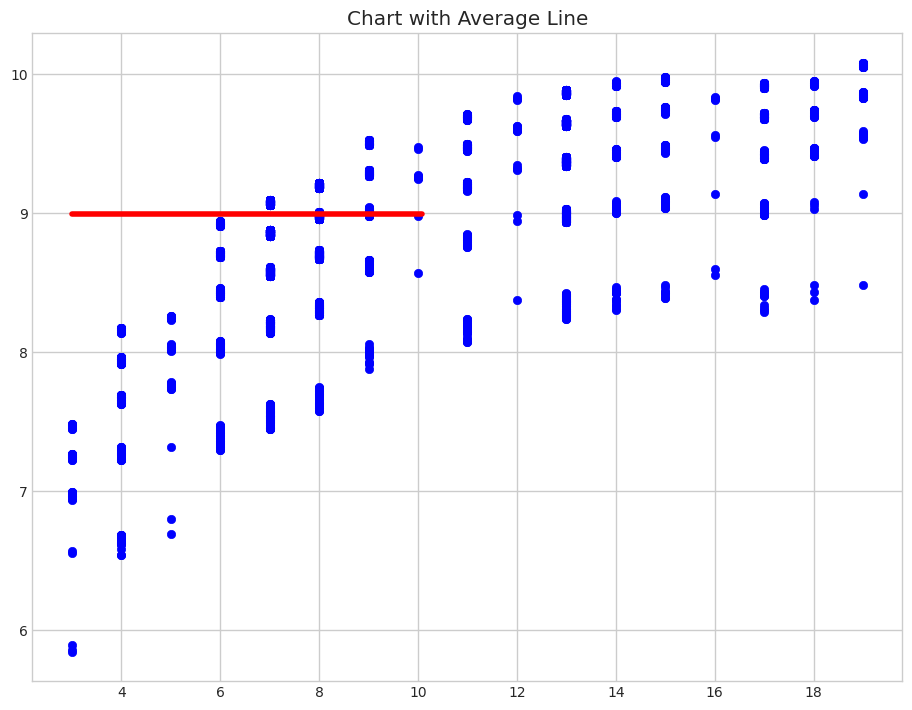

In [120]:
plt.subplots(figsize = (10,8))
ax = plt.gca()
ax.scatter(sample_train.Product_Category_1.values, sample_train.Purchase.values, color ='b');
ax.plot((sample_train.Product_Category_1.values.min(),sample_train.Purchase.values.max()), (sample_train.Purchase.values.mean(),sample_train.Purchase.values.mean()), color = 'r');
plt.title("Chart with Average Line");

In [128]:
## Calculating Mean Squared Error(MSE)
sample_train['mean_Purchase'] = sample_train.Purchase.mean()
sample_train['mse'] = np.square(sample_train.mean_Purchase - sample_train.Purchase)
sample_train.mse.mean()
## getting mse
print("Mean Squared Error(MSE) for average line is : {}".format(sample_train.mse.mean()))

Mean Squared Error(MSE) for average line is : 0.3542840487296234


In [123]:
## Calculating the beta coefficients by hand.
## mean of y.
y_bar = sample_train.Purchase.mean()
## mean of x.
x_bar = sample_train.Product_Category_1.mean() ## Calculating the beta coefficients by hand.
## mean of y.
y_bar = sample_train.Purchase.mean()
## mean of x.
x_bar = sample_train.Product_Category_1.mean()
## Std of y
std_y = sample_train.Purchase.std()
## std of x
std_x = sample_train.Product_Category_1.std()
## correlation of x and y
r_xy = sample_train.corr().loc['Product_Category_1','Purchase']
## finding beta_1
beta_1 = r_xy*(std_y/std_x)
## finding beta_0
beta_0 = y_bar - beta_1*x_bar.mean()
## Std of y
std_y = sample_train.Purchase.std()
## std of x
std_x = sample_train.Product_Category_1.std()
## correlation of x and y
r_xy = sample_train.corr().loc['Product_Category_1','Purchase']
## finding beta_1
beta_1 = r_xy*(std_y/std_x)
## finding beta_0
beta_0 = y_bar - beta_1*x_bar

<ipython-input-123-c5f0974ac6b6>:15: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  r_xy = sample_train.corr().loc['Product_Category_1','Purchase']
<ipython-input-123-c5f0974ac6b6>:25: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  r_xy = sample_train.corr().loc['Product_Category_1','Purchase']


In [124]:
## getting y_hat, which is the predicted y values.
sample_train['Linear_Yhat'] = beta_0 + beta_1*sample_train['Product_Category_1']

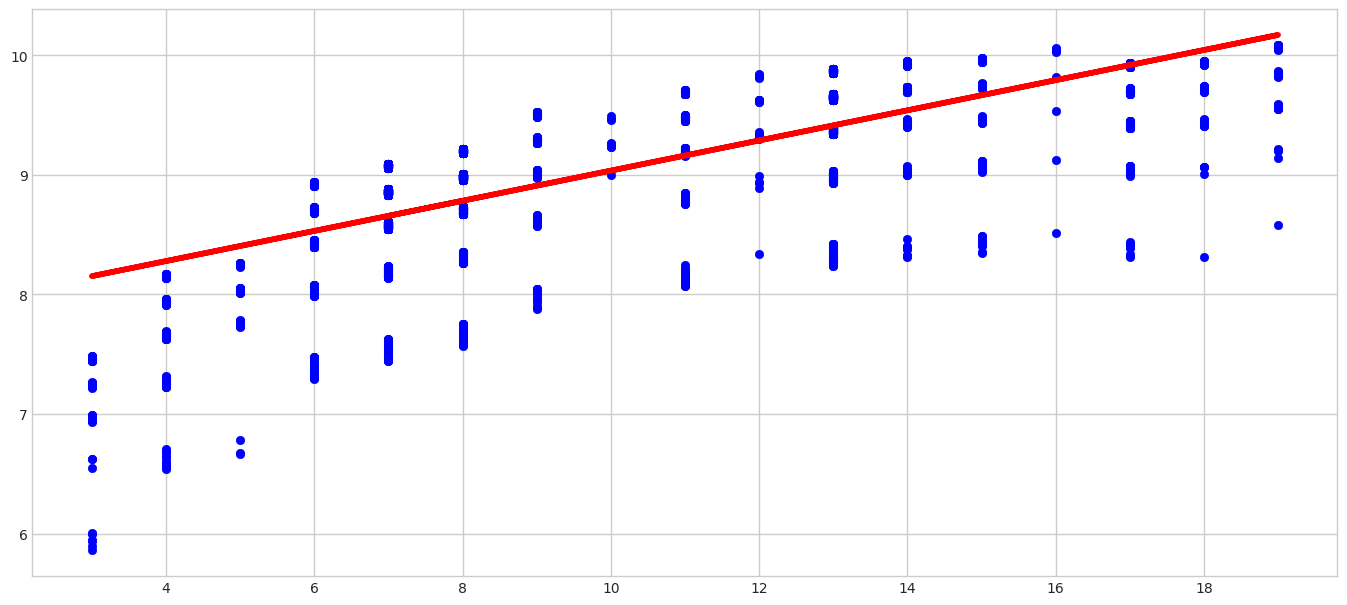

In [125]:
fig = plt.figure(figsize=(15,7))
# get the axis of that figure
ax = plt.gca()

# plot a scatter plot on it with our data
ax.scatter(sample_train.Product_Category_1, sample_train.Purchase, c='b')
ax.plot(sample_train['Product_Category_1'], sample_train['Linear_Yhat'], color='r');

In [129]:
print("Mean Squared Error(MSE) for regression line is : {}".format(np.square(sample_train['Purchase'] - sample_train['Linear_Yhat']).mean()))

Mean Squared Error(MSE) for regression line is : 0.17421009441855922


In [131]:
from sklearn.metrics import mean_squared_error
mean_squared_error(sample_train['Purchase'], sample_train.Linear_Yhat)

0.17421009441855922

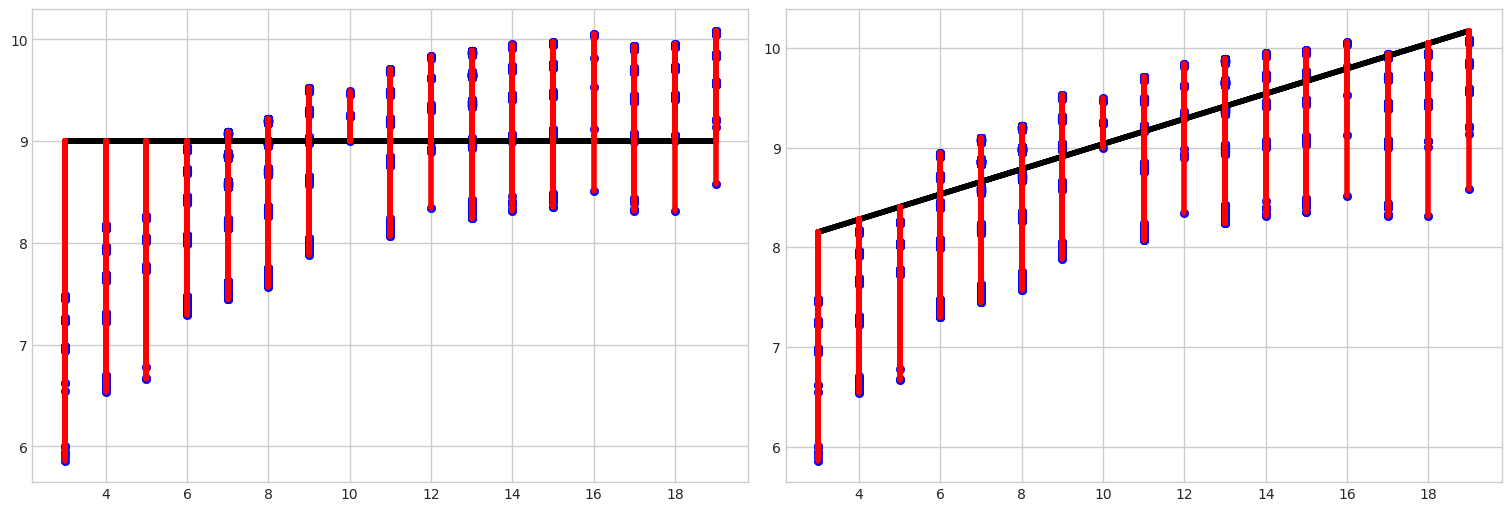

In [136]:
## Creating a customized chart. and giving in figsize and everything.
fig = plt.figure(constrained_layout=True, figsize=(15,5))
## creating a grid of 3 cols and 3 rows.
grid = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)
#gs = fig3.add_gridspec(3, 3)
#ax1 = fig.add_subplot(grid[row, column])
ax1 = fig.add_subplot(grid[0, :1])

# get the axis
ax1 = fig.gca()

# plot it
ax1.scatter(x=sample_train['Product_Category_1'], y=sample_train['Purchase'], c='b')
ax1.plot(sample_train['Product_Category_1'], sample_train['mean_Purchase'], color='k');

# iterate over predictions
for _, row in sample_train.iterrows():
    plt.plot((row['Product_Category_1'], row['Product_Category_1']), (row['Purchase'], row['mean_Purchase']), 'r-')

ax2 = fig.add_subplot(grid[0, 1:])

# plot it
ax2.scatter(x=sample_train['Product_Category_1'], y=sample_train['Purchase'], c='b')
ax2.plot(sample_train['Product_Category_1'], sample_train['Linear_Yhat'], color='k');
# iterate over predictions
for _, row in sample_train.iterrows():
    plt.plot((row['Product_Category_1'], row['Product_Category_1']), (row['Purchase'], row['Linear_Yhat']), 'r-')

In [142]:
df_train['Stay_In_Current_City_Years'] = df_train['Stay_In_Current_City_Years'].str.replace('+','')
df_train.head()

<ipython-input-142-000730376d83>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df_train['Stay_In_Current_City_Years'] = df_train['Stay_In_Current_City_Years'].str.replace('+','')


,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
0,P00069042,0,0,10,0,2,0,9,4,9.032529
1,P00248942,0,0,10,0,2,0,13,14,9.629116
2,P00087842,0,0,10,0,2,0,3,4,7.260523
3,P00085442,0,0,10,0,2,0,3,2,6.964136
4,P00285442,1,5,16,2,4,0,8,4,8.983440


In [143]:
df_train['Stay_In_Current_City_Years'] = df_train['Stay_In_Current_City_Years'].astype(int)
df_train.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
0,P00069042,0,0,10,0,2,0,9,4,9.032529
1,P00248942,0,0,10,0,2,0,13,14,9.629116
2,P00087842,0,0,10,0,2,0,3,4,7.260523
3,P00085442,0,0,10,0,2,0,3,2,6.964136
4,P00285442,1,5,16,2,4,0,8,4,8.983440


In [145]:
## importing necessary models.
## Splitting Train and Test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df_train.drop('Product_ID', axis=1), df_train['Purchase'], test_size=0.25, random_state=0)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Call in the LinearRegression object
lin_reg = LinearRegression()
## fit train and test data.
lin_reg.fit(x_train, y_train)
## Predict test data.
y_pred = lin_reg.predict(x_test)

In [146]:
## get average squared error(MSE) by comparing predicted values with real values.
print ('%.2f'%mean_squared_error(y_test, y_pred))

0.00


In [152]:
##Testing Accuracy
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)


1.0

In [157]:
##Cross checking with Cross Val score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
lr=LinearRegression()
print('MAE ',mean_absolute_error(y_test,y_pred))
np.mean(cross_val_score(lr,x_train,y_train,cv=10,scoring='r2'))

MAE  5.019129832878872e-16


1.0

## **Ridge Regression**

In [159]:
#fitting data into the model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [165]:
#r2-score for test data

x_pred_tarin = lr.predict(x_train)
r2_score(y_test,y_pred )

1.0

In [166]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(x_train, y_train)

Ridge()

In [167]:
x_pred_ridge_test = ridge.predict(x_test)
r2_score(y_test, x_pred_ridge_test)

0.9999999999014465